# Notebook 04 — Análise Comparativa de Sentimento: Atas COPOM

Este notebook unifica as bases de análise de sentimento das Atas do COPOM,
inserindo o score do modelo **Mistral** e comparando todos os modelos:
- **NLTK** (VADER)
- **TextBlob**
- **BERT** (BERTimbau)
- **FinBERT**
- **Mistral** (LLM)

Período: **2019 – 2025**

## 1. Imports e Configurações

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('tab10')

MODELOS = ['score_nltk', 'score_textblob', 'score_bert', 'score_finbert', 'score_mistral']
LABELS  = ['NLTK (VADER)', 'TextBlob', 'BERT', 'FinBERT', 'Mistral']
CORES   = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

## 2. Carregamento e Unificação das Bases

In [23]:
# Carrega base sem Mistral
df_base = pd.read_csv('/workspaces/Pred-inad-credito/base_sentimentos_modelos/base_sentimentos_copom_sem_mistral.csv')

# Carrega scores Mistral — normaliza colunas para minúsculas antes de selecionar
df_mistral = (
    pd.read_csv('/workspaces/Pred-inad-credito/base_sentimentos_modelos/base_sentimentos_copom.csv')
    .rename(columns=lambda c: c.strip().lower())        # Data→data, Score_Mistral→score_mistral
    .rename(columns={'score_mistral': 'score'})
    [['data', 'score']]
    .rename(columns={'score': 'score_mistral'})
)

# Merge pela coluna 'data'
df = df_base.merge(df_mistral, on='data', how='left')

# Organiza colunas finais
df = df[['data', 'arquivo', 'tipo', 'score_nltk', 'score_textblob',
         'score_bert', 'score_finbert', 'score_mistral']]

# Converte data
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').reset_index(drop=True)

print(f'Registros: {len(df)}')
print(f'Período: {df.data.min().date()} → {df.data.max().date()}')
df.head()

Registros: 53
Período: 2019-02-06 → 2025-12-10


,data,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-02-06,COPOM220-not20190206220.pdf,copom,-0.7783,0.0000,-0.071429,-0.248734,0.50
1,2019-03-20,COPOM221-not20190320221.pdf,copom,-0.6808,0.0000,-0.062500,-0.336417,0.65
2,2019-05-08,COPOM222-not20190508222.pdf,copom,-0.9274,0.0625,-0.125000,-0.388865,0.65
3,2019-06-19,Copom223-not20190619223.pdf,copom,-0.7783,0.0000,-0.187500,-0.407422,0.65
4,2019-07-31,Copom224-not20190731224.pdf,copom,-0.8402,0.0000,0.062500,-0.227865,0.75


## 3. Estatísticas Descritivas

In [24]:
desc = df[MODELOS].describe().T
desc.index = LABELS
desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(4)

,mean,std,min,25%,50%,75%,max
NLTK (VADER),-0.8086,0.1096,-0.9517,-0.8807,-0.8402,-0.6808,-0.4939
TextBlob,0.0123,0.0611,-0.2667,0.0000,0.0000,0.0556,0.1667
BERT,-0.1695,0.1355,-0.4167,-0.2500,-0.1667,-0.0833,0.2500
FinBERT,-0.4044,0.0990,-0.5904,-0.4599,-0.4195,-0.3393,-0.2043
Mistral,0.2123,0.5635,-0.8500,-0.3000,0.3500,0.6500,0.8500


## 5. Comparativo Sobreposto

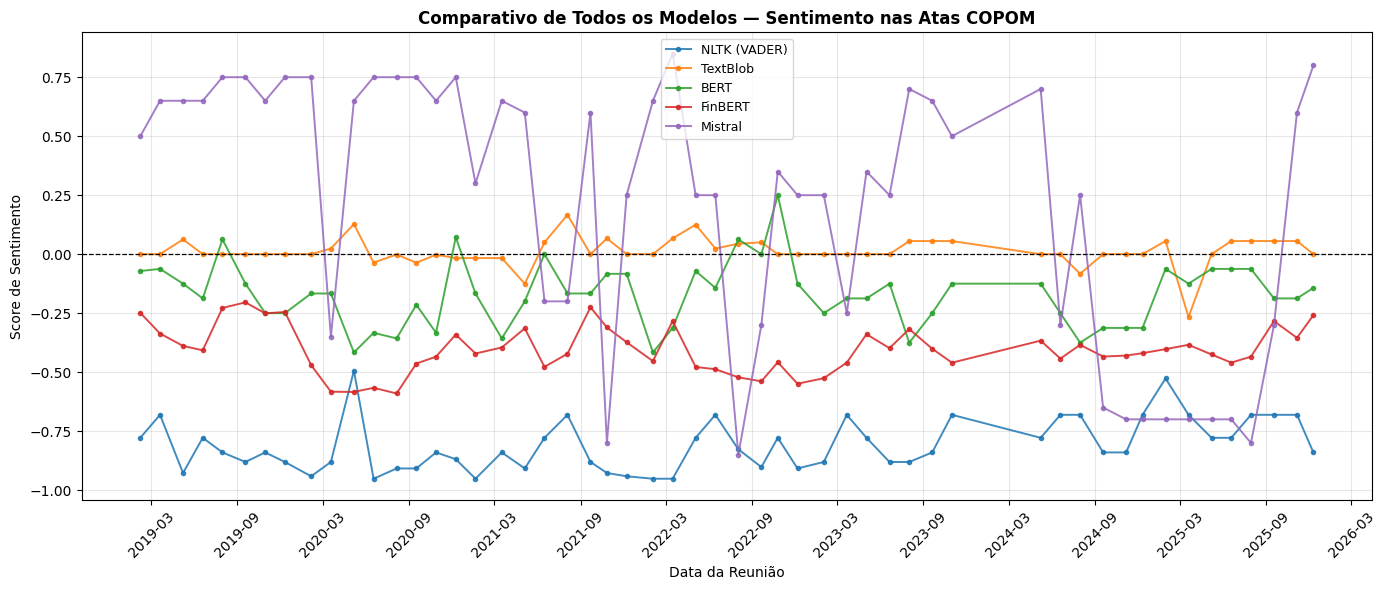

In [25]:
fig, ax = plt.subplots(figsize=(14, 6))

for col, label, cor in zip(MODELOS, LABELS, CORES):
    ax.plot(df['data'], df[col], marker='o', markersize=3,
            linewidth=1.4, label=label, color=cor, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.set_title('Comparativo de Todos os Modelos — Sentimento nas Atas COPOM',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Data da Reunião')
ax.set_ylabel('Score de Sentimento')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Análise Comparativa de Sentimento: Estatisticas

Este notebook unifica as bases de análise de sentimento das Atas do COPOM,
inserindo o score do modelo **Mistral** e comparando todos os modelos:
- **NLTK** (VADER)
- **TextBlob**
- **BERT** (BERTimbau)
- **FinBERT**
- **Mistral** (LLM)

Período: **2019 – 2025**

In [26]:
# Carrega base sem Mistral
df_base = pd.read_csv('/workspaces/Pred-inad-credito/base_sentimentos_modelos/base_sentimentos_estatisticas_sem_mistral.csv')
df_base = df_base.loc[:, ~df_base.columns.str.contains('^unnamed', case=False)]

# Carrega scores Mistral — normaliza colunas para minúsculas antes de selecionar
df_mistral = (
    pd.read_csv('/workspaces/Pred-inad-credito/base_sentimentos_modelos/base_sentimentos_estatisticas_mistral.csv')
    .rename(columns=lambda c: c.strip().lower())        # Data→data, Score_Mistral→score_mistral
    .rename(columns={'score_mistral': 'score'})
    [['data', 'score']]
    .rename(columns={'score': 'score_mistral'})
)

# Converte data antes do merge
df_base['data'] = pd.to_datetime(df_base['data'])
df_mistral['data'] = pd.to_datetime(df_mistral['data'])

# Remove duplicidades
df_base   = df_base.drop_duplicates(subset=['data']).copy()
df_mistral = df_mistral.drop_duplicates(subset=['data']).copy()

# Merge
df = df_base.merge(df_mistral, on='data', how='left', validate='one_to_one')

# Organiza colunas finais
df = df[['data', 'arquivo', 'tipo', 'score_nltk', 'score_textblob',
         'score_bert', 'score_finbert', 'score_mistral']]

df = df.sort_values('data').reset_index(drop=True)

print(f'Registros: {len(df)}')
print(f'Período: {df.data.min().date()} → {df.data.max().date()}')
print(f'Scores Mistral ausentes: {df["score_mistral"].isna().sum()}')
df.head()

Registros: 81
Período: 2019-01-01 → 2025-12-01
Scores Mistral ausentes: 0


,data,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-01-01,201901_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9969,-0.145455,-1.0,0.335325,-0.3
1,2019-02-01,201902_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9872,-0.400000,-0.5,-0.266386,-0.6
2,2019-03-01,201903_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9911,-0.320000,-1.0,0.278030,-0.3
3,2019-04-01,201904_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9934,-0.400000,-1.0,0.407023,-0.5
4,2019-05-01,201905_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9903,0.000000,-1.0,-0.195990,-0.5


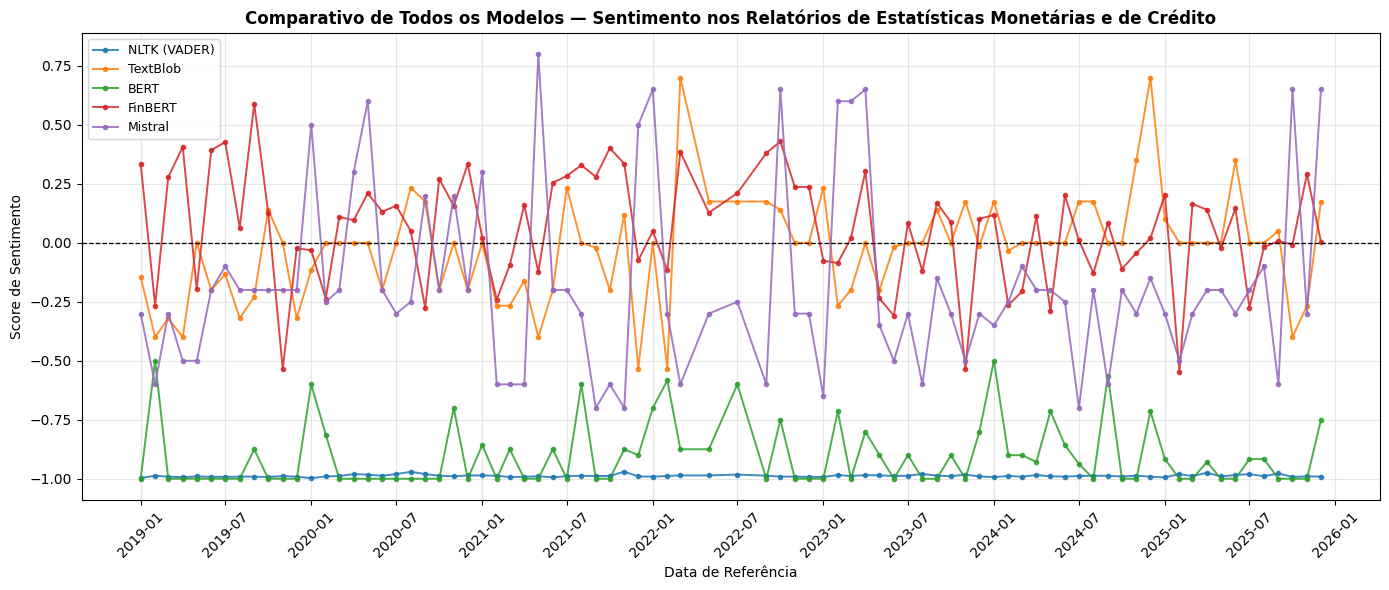

In [27]:
fig, ax = plt.subplots(figsize=(14, 6))

for col, label, cor in zip(MODELOS, LABELS, CORES):
    ax.plot(df['data'], df[col], marker='o', markersize=3,
            linewidth=1.4, label=label, color=cor, alpha=0.85)

ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
ax.set_title('Comparativo de Todos os Modelos — Sentimento nos Relatórios de Estatísticas Monetárias e de Crédito',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Data de Referência')
ax.set_ylabel('Score de Sentimento')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 11. Unificação e Exportação da Base final consolidada

In [28]:
def montar_base_sentimento(arquivo_base_sem_mistral, arquivo_mistral, tipo_relatorio):
    # Base com NLTK, TextBlob, BERT e FinBERT
    df_base = pd.read_csv(arquivo_base_sem_mistral)
    df_base = df_base.loc[:, ~df_base.columns.str.contains('^unnamed', case=False)]
    df_base = df_base.drop(columns=['score_mistral'], errors='ignore')

    # Base com score do Mistral — normaliza colunas antes de selecionar
    df_mistral = (
        pd.read_csv(arquivo_mistral)
        .rename(columns=lambda c: c.strip().lower())    # Data→data, Score_Mistral→score_mistral
        .rename(columns={'score_mistral': 'score'})
        [['data', 'score']]
        .rename(columns={'score': 'score_mistral'})
    )

    df_base['data']    = pd.to_datetime(df_base['data'])
    df_mistral['data'] = pd.to_datetime(df_mistral['data'])

    df_base    = df_base.drop_duplicates(subset=['data']).copy()
    df_mistral = df_mistral.drop_duplicates(subset=['data']).copy()

    df_unificado = df_base.merge(df_mistral, on='data', how='left', validate='one_to_one')
    df_unificado['tipo_relatorio'] = tipo_relatorio

    colunas_finais = ['data', 'tipo_relatorio', 'arquivo', 'tipo',
                      'score_nltk', 'score_textblob', 'score_bert',
                      'score_finbert', 'score_mistral']
    return df_unificado[colunas_finais]


# ── Nomes de arquivo corrigidos ───────────────────────────────────────────────
df_copom = montar_base_sentimento(
    arquivo_base_sem_mistral='/workspaces/Pred-inad-credito/base_sentimentos_modelos/base_sentimentos_copom_sem_mistral.csv',
    arquivo_mistral='/workspaces/Pred-inad-credito/base_sentimentos_modelos/base_sentimentos_copom.csv',           # era: base_sentimento_copom.csv
    tipo_relatorio='copom'
)

df_estatisticas = montar_base_sentimento(
    arquivo_base_sem_mistral='/workspaces/Pred-inad-credito/base_sentimentos_modelos/base_sentimentos_estatisticas_sem_mistral.csv',
    arquivo_mistral='/workspaces/Pred-inad-credito/base_sentimentos_modelos/base_sentimentos_estatisticas_mistral.csv',  # era: base_sentimento_estatisticas.csv
    tipo_relatorio='estatisticas'
)

df_final = pd.concat([df_copom, df_estatisticas], ignore_index=True)
df_final = df_final.sort_values(['tipo_relatorio', 'data']).reset_index(drop=True)

print(f'Registros Copom: {len(df_copom)}')
print(f'Registros Estatísticas: {len(df_estatisticas)}')
print(f'Registros totais na base final: {len(df_final)}')
print(f'Scores Mistral ausentes na base final: {df_final["score_mistral"].isna().sum()}')
df_final.head()

Registros Copom: 53
Registros Estatísticas: 81
Registros totais na base final: 134
Scores Mistral ausentes na base final: 0


,data,tipo_relatorio,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-02-06,copom,COPOM220-not20190206220.pdf,copom,-0.7783,0.0000,-0.071429,-0.248734,0.50
1,2019-03-20,copom,COPOM221-not20190320221.pdf,copom,-0.6808,0.0000,-0.062500,-0.336417,0.65
2,2019-05-08,copom,COPOM222-not20190508222.pdf,copom,-0.9274,0.0625,-0.125000,-0.388865,0.65
3,2019-06-19,copom,Copom223-not20190619223.pdf,copom,-0.7783,0.0000,-0.187500,-0.407422,0.65
4,2019-07-31,copom,Copom224-not20190731224.pdf,copom,-0.8402,0.0000,0.062500,-0.227865,0.75


In [29]:
# Exporta a base final consolidada
df_export = df_final.copy()
df_export['data'] = df_export['data'].dt.strftime('%Y-%m-%d')

df_export.to_csv('base_sentimentos.csv', index=False)

print(f'Arquivo base_sentimentos.csv exportado com {len(df_export)} registros.')
df_export


Arquivo base_sentimentos.csv exportado com 134 registros.


,data,tipo_relatorio,arquivo,tipo,score_nltk,score_textblob,score_bert,score_finbert,score_mistral
0,2019-02-06,copom,COPOM220-not20190206220.pdf,copom,-0.7783,0.000000,-0.071429,-0.248734,0.50
1,2019-03-20,copom,COPOM221-not20190320221.pdf,copom,-0.6808,0.000000,-0.062500,-0.336417,0.65
2,2019-05-08,copom,COPOM222-not20190508222.pdf,copom,-0.9274,0.062500,-0.125000,-0.388865,0.65
3,2019-06-19,copom,Copom223-not20190619223.pdf,copom,-0.7783,0.000000,-0.187500,-0.407422,0.65
4,2019-07-31,copom,Copom224-not20190731224.pdf,copom,-0.8402,0.000000,0.062500,-0.227865,0.75
...,...,...,...,...,...,...,...,...,...
129,2025-08-01,estatisticas,202508_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9894,0.000000,-0.916667,-0.018209,-0.10
130,2025-09-01,estatisticas,202509_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9776,0.050000,-1.000000,0.007749,-0.60
131,2025-10-01,estatisticas,202510_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9920,-0.400000,-1.000000,-0.007200,0.65
132,2025-11-01,estatisticas,202511_Texto_de_estatisticas_monetarias_e_de_c...,estatisticas,-0.9898,-0.266667,-1.000000,0.292047,-0.30
